# Campaign scenarios for panel-trained VID and Reference-ID calibration

This notebook compares four ways to produce total reach. They come from two separate choices: whether to add a demographic-agnostic VID model, and whether to apply a provider-supplied Reference-ID correction.

| Configuration | Total-reach source | Reference-ID correction |
|---|---|---|
| Existing VID | Current demographic-ready VID model | None |
| Agnostic VID | Separate panel-trained model that does not assign demographics | None |
| Existing VID + RID | Current VID total | Provider-supplied frozen correction |
| Agnostic VID + RID | Agnostic VID total | Provider-supplied frozen correction |

The provider may recommend any of the four after validation on whole held-out campaigns. If no extension proves better, the recommendation remains the existing VID model. The measurement-system operator runs the supplied models and instructions; it does not need to invent a calibration without truth.

An **Event Data Provider (EDP)** is a publisher or other data source contributing campaign events. A **Reference ID** is one common join-key value per person and EDP: normalized email when available, otherwise that EDP's proprietary identifier, hashed into a shared 5-billion-value space. Shared emails can match across EDPs; proprietary fallbacks have no intended cross-EDP match. “RID” is used only as a short chart and table label for Reference ID.

The synthetic harness uses exact population truth only to score the alternatives. The reporting workflow never links an existing VID to a Reference ID.

In [1]:
from pathlib import Path
import csv
import json
import sys

from IPython.display import Image, Markdown, display


def find_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "src" / "reference_calibration").exists():
            return candidate.resolve()
    raise RuntimeError("Run this notebook from the repository root or notebooks/.")


def markdown_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    separator = "|" + "|".join("---" for _ in columns) + "|"
    body = [
        "| " + " | ".join(str(row[key]).replace("|", "/") for key, _ in columns) + " |"
        for row in rows
    ]
    return "\n".join([header, separator, *body])


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "panel_5000_final"

RUN_BENCHMARK = False
if RUN_BENCHMARK:
    from reference_calibration.panel_validation import run_panel_validation
    run_panel_validation(OUTPUT_DIR, profile="quick")

summary = json.loads((OUTPUT_DIR / "panel_validation_summary.json").read_text())
with (OUTPUT_DIR / "panel_validation_metrics.csv").open() as stream:
    metrics = list(csv.DictReader(stream))
with (OUTPUT_DIR / "activation_decisions.csv").open() as stream:
    decisions = list(csv.DictReader(stream))

print(f"Panel draws per design: {summary['panel_draws_per_design']}")
print(f"Campaign scenarios: {len(summary['scenario_descriptions'])}")
print(f"Report shapes: {len(summary['report_specs'])}")

Panel draws per design: 4
Campaign scenarios: 13
Report shapes: 9


## Real-world campaign scenarios represented

The scenarios are stylized versions of campaign objectives and audience tools available in products such as Meta Ads Manager: broad awareness, traffic optimization, engagement audiences, lead generation, sales optimization, website and app retargeting, customer lists, catalog audiences, lookalikes, and automated audience expansion. They are test cases, not estimates of Meta's production delivery or match rates.

An objective label alone does not determine who is reached. Each scenario therefore varies three mechanisms independently:

- **Campaign volume:** how much of the population is reached and therefore how many panel members are observed.
- **Audience overlap across EDPs:** how strongly different publishers select the same underlying people.
- **Shared-email visibility:** how often a person reached at several publishers uses a common email-derived Reference ID at those publishers.

For example, website and app retargeting can both reach many of the same people across publishers, while the website audience may expose a shared email more often. The generator represents audience overlap with shared-versus-EDP-specific selection factors and represents matchability with a separate email-availability factor. Across the ten EDPs, base email availability ranges from 10% to 95% and the email-agreement parameter ranges from 52% to 72%, centered near the roughly 60% assumption discussed in the design. Weekly delivery is intentionally bursty rather than a smooth growth curve.

In [2]:
scenario_rows = []
for scenario, item in summary["scenario_descriptions"].items():
    scenario_rows.append({
        "objective": item["objective"],
        "audience": item["audience"],
        "volume": item["volume"],
        "similarity": item["cross_edp_similarity"],
        "matchability": item["reference_matchability"],
        "why": item["intuition"],
    })
display(Markdown(markdown_table(
    scenario_rows,
    [
        ("objective", "Objective"),
        ("audience", "Real-world campaign setup"),
        ("volume", "Relative size"),
        ("similarity", "Expected audience overlap across EDPs"),
        ("matchability", "Expected shared-email visibility"),
        ("why", "What the scenario tests"),
    ],
)))

| Objective | Real-world campaign setup | Relative size | Expected audience overlap across EDPs | Expected shared-email visibility | What the scenario tests |
|---|---|---|---|---|---|
| Awareness | Broad awareness delivery with few audience restrictions | Large | Low to moderate: each EDP reaches a broad but not identical audience | Typical for the general population | Control case: broad delivery is closest to the campaigns on which a conventional reach model is expected to work well. |
| Traffic | Interest targeting with click or landing-page optimization | Medium | Moderate: optimization can favor similar click-prone people | Typical; clicking does not require a shared email | Tests a campaign that is more selected than awareness but is not a direct retargeting audience. |
| Engagement | Engagement Custom Audience of prior video viewers or engagers | Small to medium | High: the same warm audience can be selected repeatedly | Slightly below typical; engagement does not require email | Tests high true duplication without assuming that the duplicated people are especially easy to match by email. |
| Leads | Instant Form, call, message, or signup optimization | Small | High: EDPs can converge on the same high-intent people | Above typical because lead actions often collect contact details | Tests a small conversion-oriented audience with both elevated duplication and elevated email visibility. |
| Sales | Prospecting optimized toward likely purchasers | Small to medium | High: optimization can converge on a shared pool of likely buyers | Moderately above typical | Tests algorithmic convergence on likely buyers without using a direct first-party retargeting list. |
| Sales | Website Custom Audience of recent visitors or cart viewers | Small | Very high: campaigns start from a similar first-party visitor pool | Above typical; some visitors log in, buy, or otherwise provide email | Tests the classic small retargeting case in which true cross-EDP overlap is much higher than a population-rate model expects. |
| Sales | Customer-list Custom Audience uploaded from CRM records | Very small | Very high: each EDP receives substantially the same seed list | Very high because the source audience is already email-rich | Tests the strongest upward matchability shift: a tiny audience selected from records that commonly include email. |
| Sales | Catalog retargeting or dynamic product ads | Small | High, but some EDP pairs share more products and users than others | Above typical | Tests stable pair-specific behavior rather than assuming every EDP combination matches equally well. |
| Sales | Lookalike audience built from a customer seed | Medium | Moderate to high: the same seed influences delivery, but the audience expands | Slightly above typical | Tests a middle ground between direct retargeting and broad prospecting. |
| Sales | Advantage+ audience expansion beyond the starting audience | Medium to large | Moderate: the starting signal is shared, but delivery broadens | Near typical after expansion | Tests whether a method handles a campaign that begins with a selected audience but expands toward broad delivery. |
| App promotion | App Activity Custom Audience of installers or in-app users | Small | High: the same app users can be retargeted repeatedly | Below typical when app identity is stronger than email identity | Tests high true duplication with a downward email-matchability shift—the opposite of a customer-list campaign. |
| Traffic | Different niche interests or exclusions at each EDP | Small | Low: the EDP audiences are intentionally different | Typical among the people who are reached | Negative control: the calibration should not invent duplicate reach merely because the campaigns are small. |
| Mixed | One report combining broad, traffic, lead, and retargeting campaigns | Mixed | Mixed by EDP | Mixed by EDP and audience source | Tests the realistic case in which a cross-media report combines campaigns with different objectives and audience construction. |

## The provider's training and validation flow

For each simulated panel, the provider:

1. trains the demographic-agnostic VID response on one group of campaigns;
2. fits candidate Reference-ID corrections on a separate calibration group, using weighted panel-person reach as truth and aggregate panel Reference-ID intersections as the observable signal;
3. tests each correction separately on the existing and agnostic VID totals using a third group of whole-campaign holdouts;
4. uses those holdouts to choose a complete configuration; and
5. freezes the selected model line, correction bundle, and demographic-adjustment instructions before scoring a fourth, independent group of campaigns.

Campaigns—not weekly snapshots—are held out. This prevents several cumulative observations from one campaign from masquerading as independent validation examples.

## The panel is a real 5,000-person sample in this experiment

The notebook draws a distinct panel and repeats the experiment under four recruitment conditions. The same panel supports training and validation campaigns, as it would in practice, but those campaigns remain separate. The hidden-bias condition is deliberately severe so the failure mode is visible; it is not an estimate of how common or large that bias will be in a real panel. This executed notebook uses four panel draws per condition, so selection percentages should be read as examples of behavior rather than stable production rates.

In [3]:
panel_rows = []
for design, item in summary["panel_designs"].items():
    panel_rows.append({
        "design": item["label"],
        "members": item["raw_size"],
        "effective": f"{item['effective_size']['mean']:.0f}",
        "description": item["description"],
    })
display(Markdown(markdown_table(
    panel_rows,
    [
        ("design", "Panel condition"),
        ("members", "Raw members"),
        ("effective", "Mean effective size"),
        ("description", "What it tests"),
    ],
)))

| Panel condition | Raw members | Mean effective size | What it tests |
|---|---|---|---|
| Representative panel | 5000 | 5000 | A simple random panel. Its main limitation is sampling noise. |
| 5,000 members, lower effective size | 5000 | 1374 | The panel has 5,000 members but unequal survey weights reduce the information content. |
| Observable bias, weighted | 5000 | 4455 | Age and geography affect recruitment, and known selection weights correct most of the bias. |
| Hidden intent/matchability bias | 5000 | 4492 | Recruitment also favors high-intent, email-matchable people; ordinary demographic weights cannot remove it. |

### How accurately does the panel itself represent campaign reach?

Before testing any model, the benchmark compares the panel's weighted reach estimate with full synthetic truth. “Small” means true union reach below 10% of the population, “medium” is 10%–30%, and “large” is above 30%. The p90 column is the error level that 90% of tested reports are at or below. Because the error is divided by true reach, it can exceed 100% when the true audience is small.

Sampling noise falls as campaign volume grows. Hidden audience-selection bias may not: even a large panel estimate can be systematically wrong if panel membership is related to the intent or matchability traits that drive campaign delivery.

In [4]:
panel_truth_rows = []
band_labels = {
    "small_under_10_percent": "Small (<10%)",
    "medium_10_to_30_percent": "Medium (10%–30%)",
    "large_over_30_percent": "Large (>30%)",
}
for design, bands in summary["panel_truth_summary"].items():
    for band, result in bands.items():
        panel_truth_rows.append({
            "panel": summary["panel_designs"][design]["label"],
            "volume": band_labels[band],
            "mean": f"{result['mean']:.1%}",
            "p90": f"{result['p90']:.1%}",
        })
display(Markdown(markdown_table(
    panel_truth_rows,
    [("panel", "Panel"), ("volume", "True campaign volume"), ("mean", "Mean panel-truth error"), ("p90", "p90")],
)))

| Panel | True campaign volume | Mean panel-truth error | p90 |
|---|---|---|---|
| Representative panel | Small (<10%) | 3.4% | 6.9% |
| Representative panel | Medium (10%–30%) | 2.0% | 3.8% |
| Representative panel | Large (>30%) | 0.7% | 1.7% |
| 5,000 members, lower effective size | Small (<10%) | 10.5% | 19.6% |
| 5,000 members, lower effective size | Medium (10%–30%) | 5.8% | 11.0% |
| 5,000 members, lower effective size | Large (>30%) | 2.0% | 5.1% |
| Observable bias, weighted | Small (<10%) | 5.7% | 11.5% |
| Observable bias, weighted | Medium (10%–30%) | 3.4% | 7.6% |
| Observable bias, weighted | Large (>30%) | 1.7% | 4.0% |
| Hidden intent/matchability bias | Small (<10%) | 108.2% | 161.9% |
| Hidden intent/matchability bias | Medium (10%–30%) | 51.7% | 126.1% |
| Hidden intent/matchability bias | Large (>30%) | 19.9% | 46.0% |

## Methods represented in the results

- **Existing VID** is the current demographic-ready model and its total reach.
- **Agnostic VID** is the separate panel-trained total-reach model. The production version would still be an impression-to-VID model; this harness uses a compact aggregate surrogate that learns how campaign objective, audience strategy, and EDP identity affect duplication.
- **Existing VID + RID** and **Agnostic VID + RID** use the same approved aggregate Reference-ID interface, but the provider selects and validates a correction separately for each base. A correction may be constant, fixed-plus-log-size, or a two-group matchability mixture. If no family clears the holdout rule, that path falls back to its uncorrected base.
- **Provider recommended** is the complete configuration that clears the provider's holdout rule and performs best there, with existing VID retained as the fallback.

The Reference-ID layer corrects total overlap at report time. It is not an impression-level VID model, and it does not assign demographics.

In [5]:
headline_labels = {
    "existing_vid": "Existing VID",
    "agnostic_vid": "Agnostic VID",
    "existing_plus_selected_rid": "Existing VID + selected RID",
    "agnostic_plus_selected_rid": "Agnostic VID + selected RID",
    "provider_recommended": "Provider recommended",
}
method_rows = [
    {"method": label, "description": summary["methods"][name]}
    for name, label in headline_labels.items()
]
display(Markdown(markdown_table(method_rows, [("method", "Configuration"), ("description", "Meaning")])))

| Configuration | Meaning |
|---|---|
| Existing VID | Existing demographic-ready VID architecture without Reference-ID correction. |
| Agnostic VID | Panel-trained demographic-agnostic VID result without report-level Reference-ID correction. |
| Existing VID + selected RID | Existing VID plus the Reference-ID family selected by provider panel holdouts, or identity if none passes. |
| Agnostic VID + selected RID | Demographic-agnostic VID plus the Reference-ID family selected by provider panel holdouts, or identity if none passes. |
| Provider recommended | The complete configuration selected by provider panel holdouts from the four operating configurations. |

## Accuracy of the four configurations

This is the main comparison. Mean error summarizes average performance; p90 and worst-case error show whether a configuration remains dependable for difficult reports. “+ selected RID” means the provider used only a correction that passed its whole-campaign validation for that base architecture.

The synthetic existing-VID baseline deliberately assumes that campaign overlap follows the average population pattern. It is therefore very accurate for the broad-awareness control and can be dramatically wrong for narrow, correlated audiences. The aggregate error percentages below illustrate the intended stress test; they are not estimates of current production VID accuracy. The p90 column is the error level that 90% of tested reports are at or below.

“Provider recommended” is not a fifth configuration. It reports whichever one of the four configurations the panel holdouts selected in each draw.

| Panel | Configuration | Mean error | p90 | Worst |
|---|---|---|---|---|
| Representative panel | Existing VID | 40.8% | 100.1% | 315.4% |
| Representative panel | Agnostic VID | 13.3% | 26.4% | 75.7% |
| Representative panel | Existing VID + selected RID | 8.6% | 17.1% | 100.2% |
| Representative panel | Agnostic VID + selected RID | 8.0% | 19.7% | 75.1% |
| Representative panel | Provider recommended | 8.0% | 19.7% | 75.1% |
| 5,000 members, lower effective size | Existing VID | 40.8% | 100.1% | 315.4% |
| 5,000 members, lower effective size | Agnostic VID | 13.2% | 26.1% | 74.8% |
| 5,000 members, lower effective size | Existing VID + selected RID | 8.4% | 17.6% | 102.9% |
| 5,000 members, lower effective size | Agnostic VID + selected RID | 12.3% | 25.0% | 76.9% |
| 5,000 members, lower effective size | Provider recommended | 8.4% | 17.6% | 102.9% |
| Observable bias, weighted | Existing VID | 40.8% | 100.1% | 315.4% |
| Observable bias, weighted | Agnostic VID | 13.1% | 26.7% | 74.6% |
| Observable bias, weighted | Existing VID + selected RID | 8.3% | 16.5% | 100.3% |
| Observable bias, weighted | Agnostic VID + selected RID | 8.5% | 19.6% | 76.8% |
| Observable bias, weighted | Provider recommended | 8.0% | 16.8% | 98.3% |
| Hidden intent/matchability bias | Existing VID | 40.8% | 100.1% | 315.4% |
| Hidden intent/matchability bias | Agnostic VID | 12.7% | 28.1% | 66.4% |
| Hidden intent/matchability bias | Existing VID + selected RID | 40.8% | 100.1% | 315.4% |
| Hidden intent/matchability bias | Agnostic VID + selected RID | 12.7% | 28.1% | 66.4% |
| Hidden intent/matchability bias | Provider recommended | 40.8% | 100.1% | 315.4% |

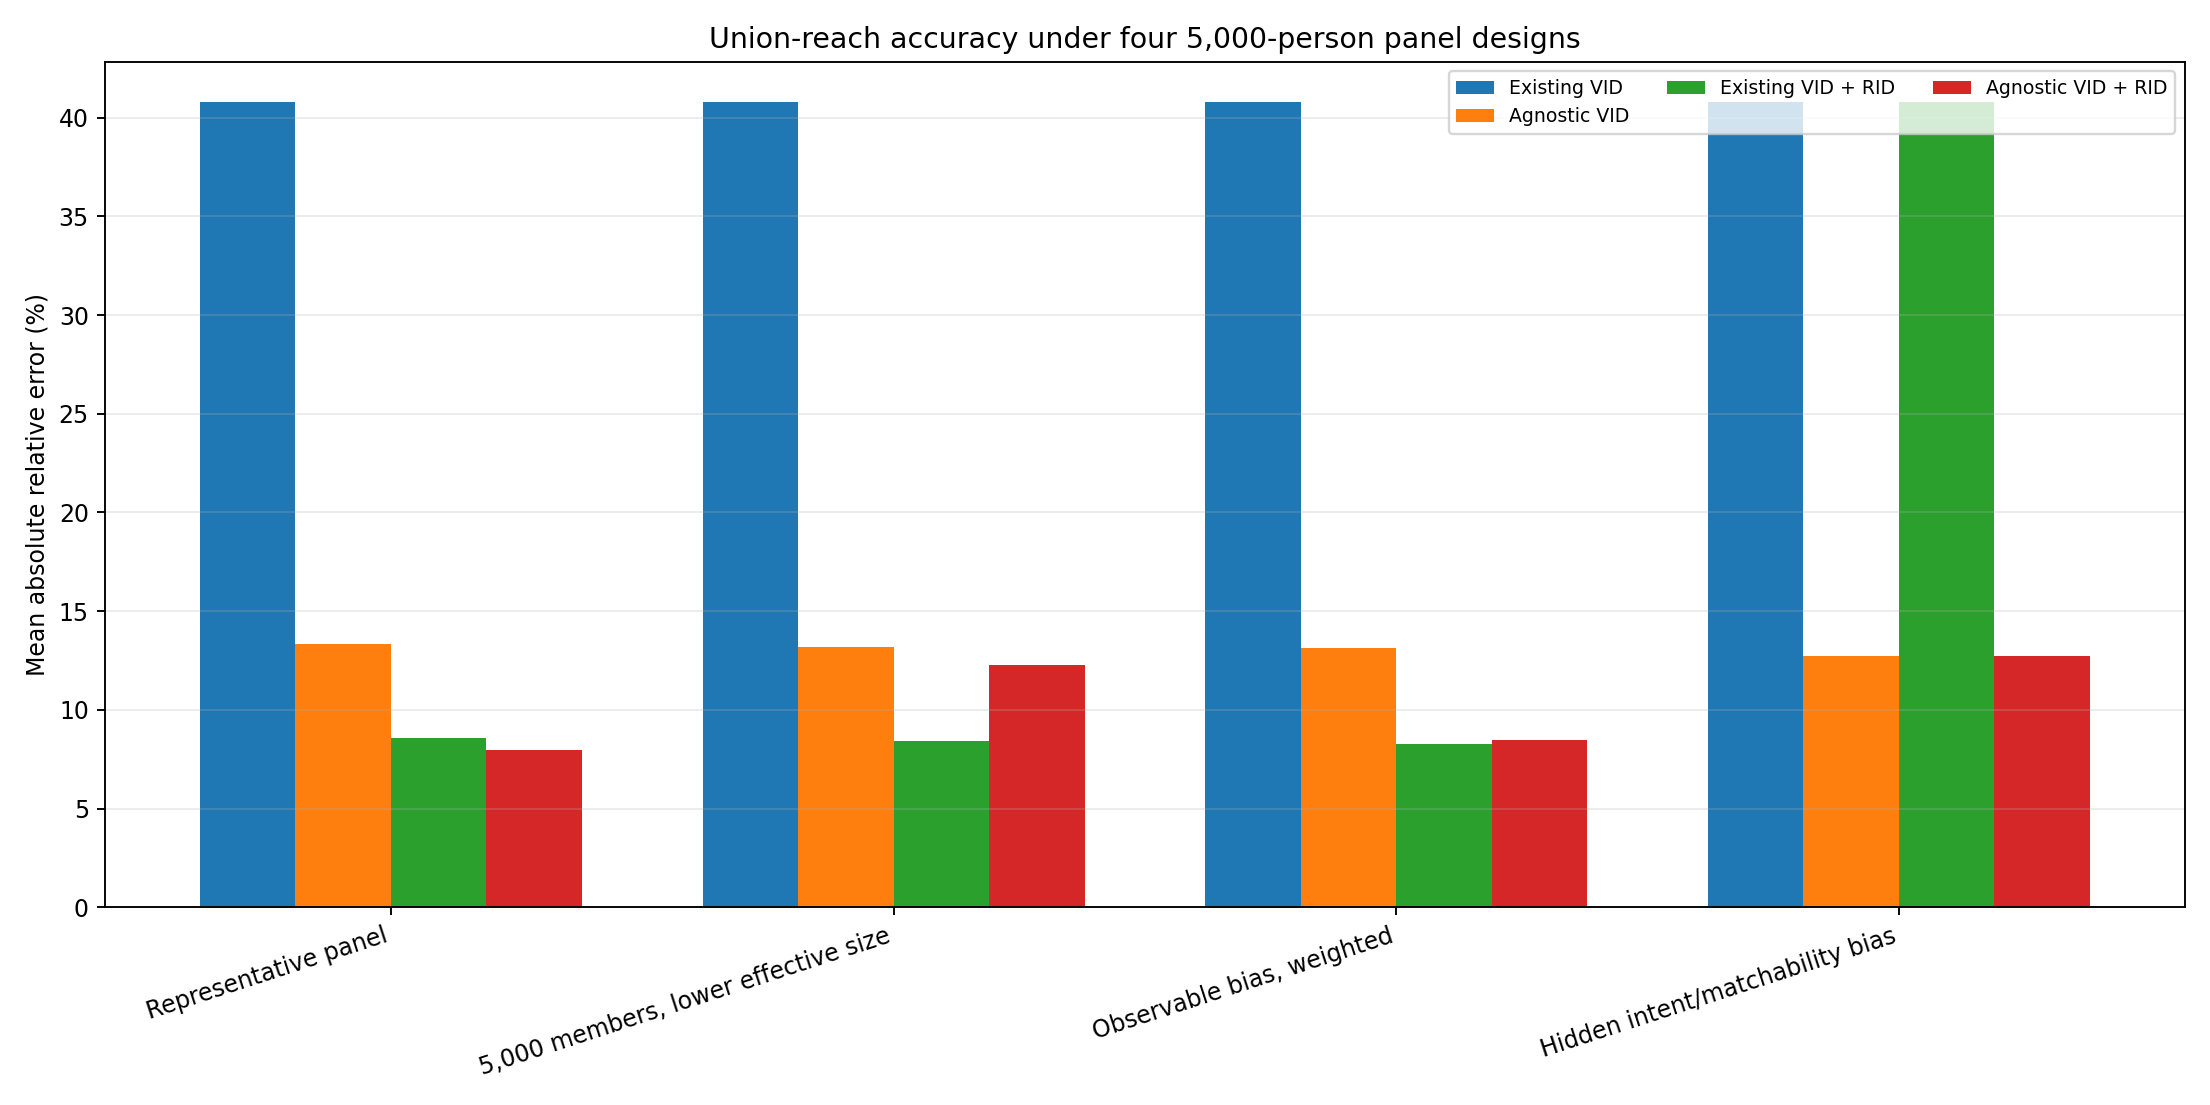

In [6]:
CONFIGURATIONS = [
    "existing_vid",
    "agnostic_vid",
    "existing_plus_selected_rid",
    "agnostic_plus_selected_rid",
    "provider_recommended",
]
configuration_labels = {
    "existing_vid": "Existing VID",
    "agnostic_vid": "Agnostic VID",
    "existing_plus_selected_rid": "Existing VID + selected RID",
    "agnostic_plus_selected_rid": "Agnostic VID + selected RID",
    "provider_recommended": "Provider recommended",
}
accuracy_rows = []
for design, design_summary in summary["method_summary"].items():
    for method in CONFIGURATIONS:
        result = design_summary[method]
        accuracy_rows.append({
            "panel": summary["panel_designs"][design]["label"],
            "method": configuration_labels[method],
            "mean": f"{result['mean']:.1%}",
            "p90": f"{result['p90']:.1%}",
            "worst": f"{result['max']:.1%}",
        })
display(Markdown(markdown_table(
    accuracy_rows,
    [("panel", "Panel"), ("method", "Configuration"), ("mean", "Mean error"), ("p90", "p90"), ("worst", "Worst")],
)))
display(Image(filename=str(OUTPUT_DIR / "error_by_panel_design.png")))

## Which campaign mechanisms remain hard?

The chart uses representative-panel draws and includes broad-awareness and unrelated-niche controls. A configuration that helps narrow retargeting but degrades broad reach should not be recommended universally. Error can exceed 100% for a small true audience; for example, 140% relative error means the estimate missed by 1.4 times the true reach.

| Scenario | Existing VID | Agnostic VID | Existing + RID | Agnostic + RID |
|---|---|---|---|---|
| Broad awareness delivery with few audience restrictions | 0.3% | 8.5% | 1.7% | 4.6% |
| Interest targeting with click or landing-page optimization | 6.4% | 9.9% | 2.5% | 2.5% |
| Engagement Custom Audience of prior video viewers or engagers | 40.8% | 9.4% | 16.1% | 10.4% |
| Instant Form, call, message, or signup optimization | 36.7% | 8.4% | 4.6% | 3.8% |
| Prospecting optimized toward likely purchasers | 33.6% | 9.1% | 2.8% | 4.2% |
| Website Custom Audience of recent visitors or cart viewers | 103.3% | 27.9% | 11.9% | 6.8% |
| Customer-list Custom Audience uploaded from CRM records | 142.3% | 30.7% | 11.1% | 16.9% |
| Catalog retargeting or dynamic product ads | 40.8% | 13.0% | 3.9% | 4.5% |
| Lookalike audience built from a customer seed | 17.3% | 9.0% | 3.9% | 4.5% |
| Advantage+ audience expansion beyond the starting audience | 15.4% | 8.8% | 2.0% | 4.3% |
| App Activity Custom Audience of installers or in-app users | 79.5% | 18.5% | 44.3% | 28.3% |
| Different niche interests or exclusions at each EDP | 12.0% | 10.2% | 4.6% | 8.5% |
| One report combining broad, traffic, lead, and retargeting campaigns | 1.8% | 9.9% | 1.8% | 4.0% |

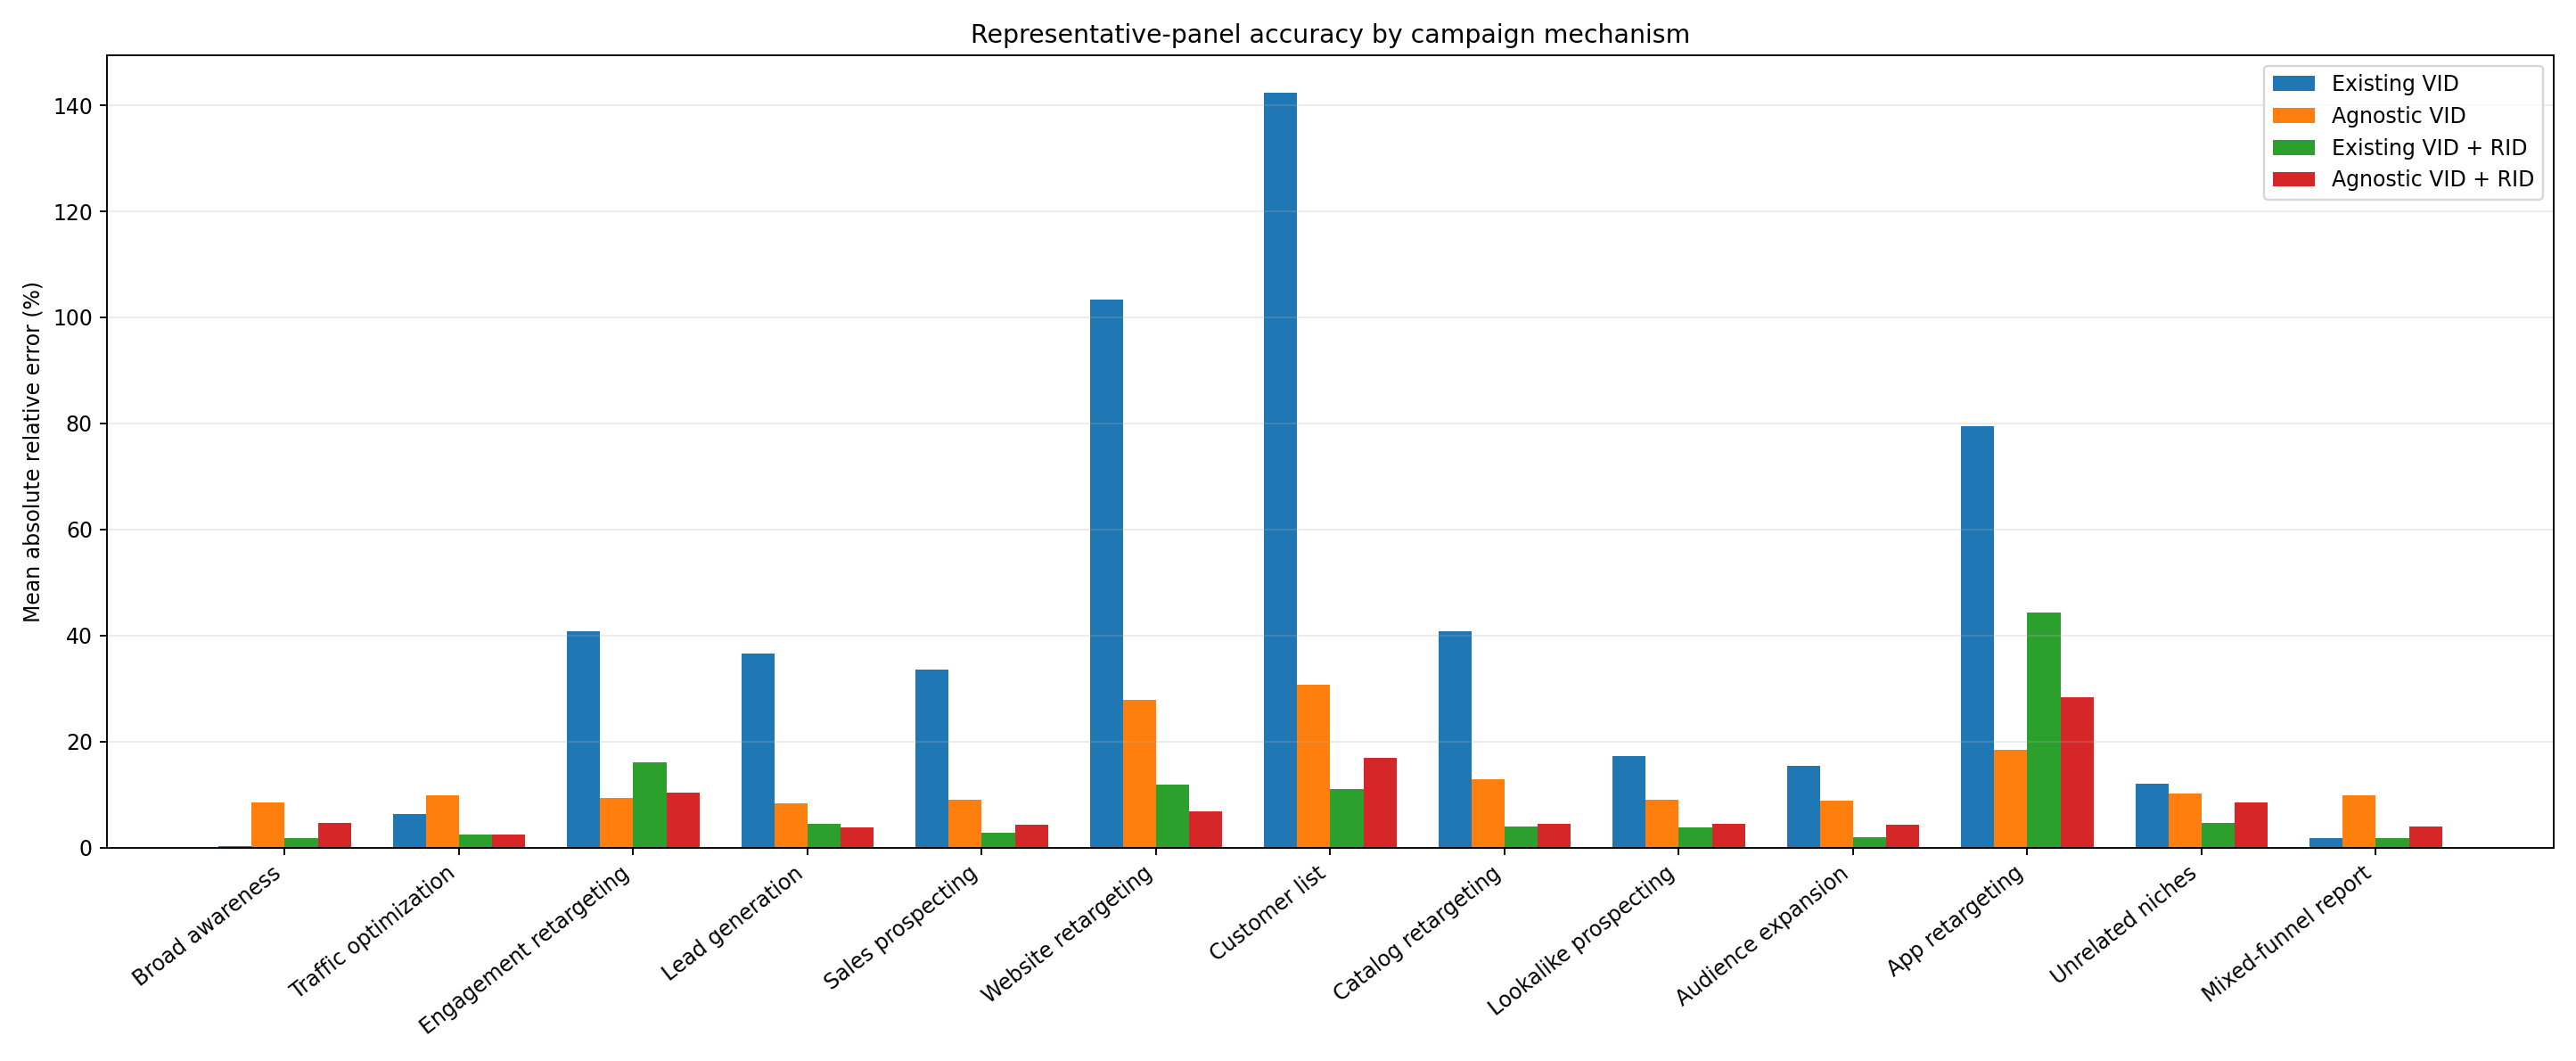

In [7]:
scenario_result_rows = []
for scenario, results in summary["scenario_summary"].items():
    scenario_result_rows.append({
        "scenario": summary["scenario_descriptions"][scenario]["audience"],
        "existing": f"{results['existing_vid']['mean']:.1%}",
        "agnostic": f"{results['agnostic_vid']['mean']:.1%}",
        "existing_rid": f"{results['existing_plus_selected_rid']['mean']:.1%}",
        "agnostic_rid": f"{results['agnostic_plus_selected_rid']['mean']:.1%}",
    })
display(Markdown(markdown_table(
    scenario_result_rows,
    [
        ("scenario", "Scenario"),
        ("existing", "Existing VID"),
        ("agnostic", "Agnostic VID"),
        ("existing_rid", "Existing + RID"),
        ("agnostic_rid", "Agnostic + RID"),
    ],
)))
display(Image(filename=str(OUTPUT_DIR / "error_by_campaign_scenario.png")))

## What does the provider select?

Each panel draw makes three related decisions:

1. whether a Reference-ID correction improves the existing VID base;
2. whether a Reference-ID correction improves the agnostic VID base; and
3. which of the four complete configurations should be recommended.

The holdout rule requires a meaningful average improvement, no material p90 regression, and campaign-level evidence that the improvement is unlikely to be sampling noise. The truth-error-change column uses hidden synthetic truth to audit whether the provider's panel-based choice generalized. A raw nested-report violation means that, before reconciliation, a smaller week or EDP scope reported more reach than a larger scope containing it.

In [8]:
activation_rows = []
for design, item in summary["activation_summary"].items():
    recommended = ", ".join(
        f"{configuration_labels.get(name, name)}: {count}"
        for name, count in item["recommended_configuration_counts"].items()
        if count
    )
    activation_rows.append({
        "panel": summary["panel_designs"][design]["label"],
        "existing_active": f"{item['existing_correction_active_rate']:.0%}",
        "agnostic_active": f"{item['agnostic_correction_active_rate']:.0%}",
        "recommended": recommended,
        "change": f"{item['mean_recommended_error_change_vs_existing']:+.1%}",
        "violations": f"{item['raw_consistency_violation_rate']:.1%}",
    })
display(Markdown(markdown_table(
    activation_rows,
    [
        ("panel", "Panel"),
        ("existing_active", "RID active on existing"),
        ("agnostic_active", "RID active on agnostic"),
        ("recommended", "Provider recommendation(s)"),
        ("change", "Truth-error change vs existing"),
        ("violations", "Raw nested-report violations"),
    ],
)))

| Panel | RID active on existing | RID active on agnostic | Provider recommendation(s) | Truth-error change vs existing | Raw nested-report violations |
|---|---|---|---|---|---|
| Representative panel | 100% | 100% | Agnostic VID + selected RID: 4 | -32.8% | 0.5% |
| 5,000 members, lower effective size | 100% | 25% | Existing VID + selected RID: 4 | -32.4% | 1.9% |
| Observable bias, weighted | 100% | 100% | Existing VID + selected RID: 3, Agnostic VID + selected RID: 1 | -32.8% | 1.9% |
| Hidden intent/matchability bias | 0% | 0% | Existing VID: 4 | +0.0% | 0.0% |

In [9]:
hidden = summary["method_summary"]["hidden_matchability_bias"]
hidden_choice = summary["activation_summary"]["hidden_matchability_bias"]["recommended_configuration_counts"]
draw_count = sum(hidden_choice.values())
choice_text = ", ".join(
    f"**{configuration_labels[name]}** in {count} of {draw_count} draws"
    for name, count in hidden_choice.items()
    if count
)
display(Markdown(
    "**Important stress result.** Under hidden intent/matchability bias, the provider's "
    f"panel selected {choice_text}. The recommended configuration's full-population mean "
    f"error was **{hidden['provider_recommended']['mean']:.1%}**; for comparison, agnostic VID alone "
    f"had **{hidden['agnostic_vid']['mean']:.1%}** error. This is a deliberate demonstration "
    "that disciplined holdout selection cannot repair a panel that systematically misses the audience trait driving delivery."
))

**Important stress result.** Under hidden intent/matchability bias, the provider's panel selected **Existing VID** in 4 of 4 draws. The recommended configuration's full-population mean error was **40.8%**; for comparison, agnostic VID alone had **12.7%** error. This is a deliberate demonstration that disciplined holdout selection cannot repair a panel that systematically misses the audience trait driving delivery.

## Why low-volume campaigns are difficult with 5,000 people

With an effective panel of 5,000, a campaign reaching 1% of the population contains about 50 reached panelists on average. Its approximate 95% relative sampling uncertainty is about 28% before weighting, overlap estimation, or selection bias. A 0.2% intersection contains about 10 expected panelists and has roughly 62% relative uncertainty.

The panel can therefore learn pooled behavior across many campaigns. It generally cannot provide a precise standalone truth label for every small campaign or higher-order overlap. Hidden selection bias is more serious: repeated sampling does not remove a systematic difference between panelists and the campaign audience.

In [10]:
count_rows = []
for reach_fraction in (0.20, 0.10, 0.05, 0.01, 0.005, 0.001):
    expected = 5_000 * reach_fraction
    relative_95 = 1.96 * ((reach_fraction * (1 - reach_fraction) / 5_000) ** 0.5) / reach_fraction
    count_rows.append({
        "reach": f"{reach_fraction:.1%}",
        "people": f"{expected:.0f}",
        "uncertainty": f"±{relative_95:.0%}",
    })
display(Markdown(markdown_table(
    count_rows,
    [("reach", "Population reach"), ("people", "Expected panelists"), ("uncertainty", "Approx. 95% relative uncertainty")],
)))

| Population reach | Expected panelists | Approx. 95% relative uncertainty |
|---|---|---|
| 20.0% | 1000 | ±6% |
| 10.0% | 500 | ±8% |
| 5.0% | 250 | ±12% |
| 1.0% | 50 | ±28% |
| 0.5% | 25 | ±39% |
| 0.1% | 5 | ±88% |

## Demographic output is a separate provider instruction

The measurement system always runs the demographic-ready VID model. When the selected total comes from the agnostic model or a Reference-ID correction, a provider-supplied demographic adjustment maps the existing VID demographic distribution to that total.

The benchmark compares simple proportional scaling with a panel-learned contextual adjustment. “Distribution error” measures how far the reported shares across demographic buckets differ from truth; lower is better. The Reference-ID layer itself does not identify which age, gender, or geography bucket should change. It only changes total union reach.

In [11]:
demo_methods = (
    "existing_vid",
    "agnostic_proportional_demo",
    "agnostic_panel_demo",
    "existing_rid_panel_demo",
    "agnostic_rid_panel_demo",
    "recommended_panel_demo",
)
demo_labels = {
    "existing_vid": "Existing VID demographics",
    "agnostic_proportional_demo": "Agnostic total + proportional scaling",
    "agnostic_panel_demo": "Agnostic total + panel adjustment",
    "existing_rid_panel_demo": "Existing + RID total + panel adjustment",
    "agnostic_rid_panel_demo": "Agnostic + RID total + panel adjustment",
    "recommended_panel_demo": "Recommended total + panel adjustment",
}
demo_rows = []
for design in summary["panel_designs"]:
    for method in demo_methods:
        values = [
            float(row["value"])
            for row in metrics
            if row["panel_design"] == design
            and row["category"] == "demographic_distribution_error"
            and row["method"] == method
        ]
        demo_rows.append({
            "panel": summary["panel_designs"][design]["label"],
            "method": demo_labels[method],
            "mean": f"{sum(values) / len(values):.1%}",
        })
display(Markdown(markdown_table(
    demo_rows,
    [("panel", "Panel"), ("method", "Demographic output"), ("mean", "Mean distribution error")],
)))

| Panel | Demographic output | Mean distribution error |
|---|---|---|
| Representative panel | Existing VID demographics | 6.4% |
| Representative panel | Agnostic total + proportional scaling | 6.3% |
| Representative panel | Agnostic total + panel adjustment | 4.1% |
| Representative panel | Existing + RID total + panel adjustment | 4.1% |
| Representative panel | Agnostic + RID total + panel adjustment | 4.2% |
| Representative panel | Recommended total + panel adjustment | 4.2% |
| 5,000 members, lower effective size | Existing VID demographics | 6.4% |
| 5,000 members, lower effective size | Agnostic total + proportional scaling | 6.3% |
| 5,000 members, lower effective size | Agnostic total + panel adjustment | 5.7% |
| 5,000 members, lower effective size | Existing + RID total + panel adjustment | 5.7% |
| 5,000 members, lower effective size | Agnostic + RID total + panel adjustment | 5.7% |
| 5,000 members, lower effective size | Recommended total + panel adjustment | 5.7% |
| Observable bias, weighted | Existing VID demographics | 6.4% |
| Observable bias, weighted | Agnostic total + proportional scaling | 6.3% |
| Observable bias, weighted | Agnostic total + panel adjustment | 4.5% |
| Observable bias, weighted | Existing + RID total + panel adjustment | 4.5% |
| Observable bias, weighted | Agnostic + RID total + panel adjustment | 4.4% |
| Observable bias, weighted | Recommended total + panel adjustment | 4.5% |
| Hidden intent/matchability bias | Existing VID demographics | 6.4% |
| Hidden intent/matchability bias | Agnostic total + proportional scaling | 6.4% |
| Hidden intent/matchability bias | Agnostic total + panel adjustment | 6.7% |
| Hidden intent/matchability bias | Existing + RID total + panel adjustment | 7.5% |
| Hidden intent/matchability bias | Agnostic + RID total + panel adjustment | 6.7% |
| Hidden intent/matchability bias | Recommended total + panel adjustment | 6.4% |

## Report combinations tested

Every frozen configuration is tested on early and later cumulative reports, partial and noncontiguous windows, and 2-, 5-, and 10-EDP requests. This includes the operational case where weeks 1–3 are reported first and weeks 1–12 are requested later.

In [12]:
report_rows = [
    {
        "report": {
            "weeks_1_3__2_edps": "Early cumulative report",
            "weeks_5_12__2_edps": "Later partial window",
            "all_weeks__2_edps": "Full flight, two EDPs",
            "weeks_7_13__5_edps": "Late-flight window",
            "all_weeks__5_edps": "Full flight, five EDPs",
            "noncontiguous__5_edps": "Selected noncontiguous weeks",
            "weeks_1_3__10_edps": "Early cumulative, all EDPs",
            "weeks_1_12__10_edps": "Later cumulative, all EDPs",
            "all_weeks__10_edps": "Full flight, all EDPs",
        }[item["label"]],
        "weeks": ", ".join(map(str, item["weeks"])),
        "edps": len(item["edps"]),
    }
    for item in summary["report_specs"]
]
display(Markdown(markdown_table(report_rows, [("report", "Report"), ("weeks", "Weeks"), ("edps", "EDPs")])))

| Report | Weeks | EDPs |
|---|---|---|
| Early cumulative report | 1, 2, 3 | 2 |
| Later partial window | 5, 6, 7, 8, 9, 10, 11, 12 | 2 |
| Full flight, two EDPs | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13 | 2 |
| Late-flight window | 7, 8, 9, 10, 11, 12, 13 | 5 |
| Full flight, five EDPs | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13 | 5 |
| Selected noncontiguous weeks | 1, 3, 5, 8, 11, 13 | 5 |
| Early cumulative, all EDPs | 1, 2, 3 | 10 |
| Later cumulative, all EDPs | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 | 10 |
| Full flight, all EDPs | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13 | 10 |

## Interpretation

- The two architecture choices should be evaluated separately. A useful agnostic model does not prove that Reference-ID correction is needed, and a useful Reference-ID correction does not require an agnostic model.
- The same correction family can be proposed for both base architectures, but its activation and complete bundle must be validated separately because the residual errors differ.
- A 5,000-person panel can support pooled training across many campaigns, but individual small-campaign labels and high-order intersections remain noisy.
- Observable weighting does not solve hidden selection related to intent or email matchability.
- A provider can publish an identity correction when no Reference-ID family proves incremental value. Shadow measurement can still monitor implementation and drift.
- A valid audience reconstruction removes contradictions inside one report. Independent report requests can still disagree, so stored-result reconciliation remains a separate reporting safeguard.

These are synthetic findings, not production performance claims. The next evidence should come from repeated real-panel resampling, whole-campaign holdouts, and external truth where available.